In [3]:
import os

dataset_path = r"D:\gesture_project\Image_Finger Project Dataset\Image_Finger Project Dataset"

print("Dataset exists:", os.path.exists(dataset_path))
print("Classes:", os.listdir(dataset_path))

Dataset exists: True
Classes: ['Open Palm🖐️', 'Peace✌️', 'Point Up☝️', 'Thumbs up👍']


In [4]:
import os

dataset_path = r"D:\gesture_project\Image_Finger Project Dataset\Image_Finger Project Dataset"


classes = os.listdir(dataset_path)

print("Total Classes:", len(classes))
print("-" * 40)

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):
        images = os.listdir(class_path)

        print(f"Class Name: {cls}")
        print(f"Total Images: {len(images)}")

       
        print("Sample Images:", images[:5])
        print("-" * 40)

Total Classes: 4
----------------------------------------
Class Name: Open Palm🖐️
Total Images: 94
Sample Images: ['IMG-20260519-WA0009.jpg', 'IMG-20260519-WA0010.jpg', 'IMG-20260519-WA0011.jpg', 'IMG-20260519-WA0012.jpg', 'IMG-20260519-WA0013.jpg']
----------------------------------------
Class Name: Peace✌️
Total Images: 96
Sample Images: ['IMG-20260519-WA0023.jpg', 'IMG-20260519-WA0024.jpg', 'IMG-20260519-WA0025.jpg', 'IMG-20260519-WA0026.jpg', 'IMG-20260519-WA0027.jpg']
----------------------------------------
Class Name: Point Up☝️
Total Images: 90
Sample Images: ['IMG-20260519-WA0049.jpg', 'IMG-20260519-WA0050.jpg', 'IMG-20260519-WA0051.jpg', 'IMG-20260519-WA0052.jpg', 'IMG-20260519-WA0053.jpg']
----------------------------------------
Class Name: Thumbs up👍
Total Images: 94
Sample Images: ['3bf13c7239964cb5624935b92b710f79.jpg', '44219d1b3327b3ae9a6dcf084f912c3a.jpg', '4d08dc95bcb3b2a17db825d2642743aa.jpg', '66263c36b8ba691fe5430fa8fffb237c.jpg', 'a59c0c4431f83ff5cf3e2092c822bb1

In [5]:
pip install mediapipe opencv-python numpy scikit-learn tensorflow matplotlib seaborn

  Using cached protobuf-7.35.0-cp310-abi3-win_amd64.whl (439 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.3
    Uninstalling protobuf-4.25.3:
      Successfully uninstalled protobuf-4.25.3
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install mediapipe opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import mediapipe as mp
import cv2
import numpy as np
import os
from glob import glob

print(" MediaPipe:", mp.__version__)
print(" OpenCV:", cv2.__version__)
print(" All done")

 MediaPipe: 0.10.35
 OpenCV: 4.13.0
 All done


In [9]:
import platform
print(platform.python_version())

3.10.11


In [10]:
import mediapipe as mp

print("Path:", mp.__file__)
print("Version:", mp.__version__)
print(hasattr(mp, "solutions"))

Path: c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\mediapipe\__init__.py
Version: 0.10.35
False


In [11]:
pip uninstall mediapipe -y

Found existing installation: mediapipe 0.10.35Note: you may need to restart the kernel to use updated packages.



Uninstalling mediapipe-0.10.35:
  Successfully uninstalled mediapipe-0.10.35


In [12]:
pip uninstall mediapipe -y

Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install mediapipe==0.10.9

  Using cached mediapipe-0.10.9-cp310-cp310-win_amd64.whl (50.5 MB)
  Using cached protobuf-3.20.3-cp310-cp310-win_amd64.whl (904 kB)
  Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.0
    Uninstalling protobuf-7.35.0:
      Successfully uninstalled protobuf-7.35.0
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\ASUS\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\google\\~~pb\\_message.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import mediapipe as mp
import cv2
import numpy as np
import os
from glob import glob

print("MediaPipe:", mp.__version__)
print("All good!")

MediaPipe: 0.10.9
All good!


In [2]:
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.3
)

dataset_path = r"D:\gesture_project\Image_Finger Project Dataset\Image_Finger Project Dataset"
save_dir = r"D:\gesture_project\results"
os.makedirs(save_dir, exist_ok=True)

print("Classes:", os.listdir(dataset_path))
print(" Ready!")

Classes: ['Open Palm🖐️', 'Peace✌️', 'Point Up☝️', 'Thumbs up👍']
 Ready!


In [ ]:
import numpy as np
from PIL import Image

def extract_landmarks(image_path):
    
    try:
        pil_img = Image.open(image_path).convert('RGB')
        pil_img = pil_img.resize((640, 480))
        img_rgb = np.array(pil_img)
        
        result = hands.process(img_rgb)
        if result.multi_hand_landmarks:
            coords = []
            for lm in result.multi_hand_landmarks[0].landmark:
                coords.extend([lm.x, lm.y, lm.z])
            return np.array(coords)
    except Exception as e:
        pass
    return None


test_class = os.listdir(dataset_path)[0]
test_folder = os.path.join(dataset_path, test_class)
test_imgs = glob(os.path.join(test_folder, "*.jpg"))
test_img_path = test_imgs[0]

result = extract_landmarks(test_img_path)
print("Landmarks extracted:", result is not None)
if result is not None:
    print("Shape:", result.shape)

Landmarks extracted: True
Shape: (63,)


In [6]:
X, y = [], []
class_names = sorted(os.listdir(dataset_path))

for label, class_name in enumerate(class_names):
    folder = os.path.join(dataset_path, class_name)
    images = glob(os.path.join(folder, "*.jpg")) + \
             glob(os.path.join(folder, "*.jpeg")) + \
             glob(os.path.join(folder, "*.png"))

    success, failed = 0, 0
    for img_path in images:
        lm = extract_landmarks(img_path)
        if lm is not None:
            X.append(lm)
            y.append(label)
            success += 1
        else:
            failed += 1

    print(f"{class_name}: {success} success, {failed} failed")

X = np.array(X)
y = np.array(y)
print(f"\nTotal: {len(X)} samples extracted! ")

Open Palm🖐️: 84 success, 9 failed
Peace✌️: 59 success, 37 failed
Point Up☝️: 68 success, 21 failed
Thumbs up👍: 79 success, 15 failed

Total: 290 samples extracted! 


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import pickle
import numpy as np

# -----------------------------
# 1. TRAIN / TEST SPLIT FIRST
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# 2. TRAIN / VAL SPLIT
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# -----------------------------
# 3. SCALING (ONLY ON TRAIN)
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# -----------------------------
# 4. ONE HOT ENCODING
# -----------------------------
num_classes = len(np.unique(y))

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

# -----------------------------
# 5. MODEL BUILDING
# -----------------------------
mlp = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

mlp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# 6. CALLBACKS
# -----------------------------
callbacks = [
    EarlyStopping(
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{save_dir}/mediapipe_model.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# -----------------------------
# 7. TRAIN MODEL
# -----------------------------
history = mlp.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=16,
    callbacks=callbacks
)

# -----------------------------
# 8. SAVE SCALER
# -----------------------------
with open(f"{save_dir}/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Training complete!")

Train: 197 | Val: 35 | Test: 58


d:\gesture_project\mp_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3153 - loss: 1.7048
Epoch 1: val_accuracy improved from None to 0.45714, saving model to D:\gesture_project\results/mediapipe_model.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.4112 - loss: 1.4201 - val_accuracy: 0.4571 - val_loss: 1.2537
Epoch 2/100
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4375 - loss: 1.2142
Epoch 2: val_accuracy improved from 0.45714 to 0.60000, saving model to D:\gesture_project\results/mediapipe_model.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5584 - loss: 0.9812 - val_accuracy: 0.6000 - val_loss: 1.0947
Epoch 3/100
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8750 - loss: 0.4806
Epoch 3: val_accuracy improved from 0.60000 to 0.68571, saving model to D:\gesture_project\results/mediapipe_model.h5


...

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8325 - loss: 0.5125 - val_accuracy: 0.7714 - val_loss: 0.8552
Epoch 5/100
 8/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8442 - loss: 0.5651  
Epoch 5: val_accuracy did not improve from 0.77143
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8426 - loss: 0.4812 - val_accuracy: 0.7714 - val_loss: 0.7635
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8805 - loss: 0.4157 
Epoch 6: val_accuracy improved from 0.77143 to 0.85714, saving model to D:\gesture_project\results/mediapipe_model.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8223 - loss: 0.5167 - val_accuracy: 0.8571 - val_loss: 0.6680
Epoch 7/100
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8125 - loss: 0.7138
Epoch 7: val_accuracy improved from 0.85714 to 0.88571, saving model to D:\gesture_project\results/mediapipe_model.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8528 - loss: 0.4108 - val_accuracy: 0.8857 - val_loss: 0.6048
Epoch 8/100
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9375 - loss: 0.2874
Epoch 8: val_accuracy improved from 0.88571 to 0.94286, saving model to D:\gesture_project\results/mediapipe_model.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8832 - loss: 0.3261 - val_accuracy: 0.9429 - val_loss: 0.5473
Epoch 9/100
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9375 - loss: 0.3377
Epoch 9: val_accuracy did not improve from 0.94286
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8528 - loss: 0.3593 - val_accuracy: 0.9429 - val_loss: 0.5031
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8791 - loss: 0.3317 
Epoch 10: val_accuracy did not improve from 0.94286
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9188 - loss: 0.2774 - val_accuracy: 0.9429 - val_loss: 0.4666
Epoch 11/100
11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8766 - loss: 0.3695 
Epoch 11: val_accuracy did not improve from 0.94286
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8832 - loss: 0.3608 - val_accuracy: 0.9429 - val_loss: 0.4298
Epoch 12/100
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9375 - loss: 0.2386
Epoch 12: val_accuracy did not imp

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9543 - loss: 0.1058 - val_accuracy: 0.9714 - val_loss: 0.2371
Epoch 32/100
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 0.0595
Epoch 32: val_accuracy did not improve from 0.97143
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9340 - loss: 0.1595 - val_accuracy: 0.9714 - val_loss: 0.2177
Epoch 33/100
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9375 - loss: 0.1987
Epoch 33: val_accuracy did not improve from 0.97143
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9543 - loss: 0.1391 - val_accuracy: 0.9714 - val_loss: 0.2198
Epoch 34/100
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9375 - loss: 0.1009
Epoch 34: val_accuracy did not improve from 0.97143
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9645 - loss: 0.0868 - val_accuracy: 0.9143 - val_loss: 0.2523
Epoch 35/100
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8750 - loss: 0.3750
Epoch 35: val_accuracy did not impr


 Test Accuracy: 89.66%
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step 


d:\gesture_project\mp_env\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128400 (\N{RAISED HAND WITH FINGERS SPLAYED}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\gesture_project\mp_env\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14736\197856325.py:21: UserWarning: Glyph 128400 (\N{RAISED HAND WITH FINGERS SPLAYED}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{save_dir}/mediapipe_confusion_matrix.png", dpi=150)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14736\197856325.py:21: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{save_dir}/mediapipe_confusion_matrix.png", dpi=150)
d:\gesture_project\mp_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128400 (\N{RAISED HAND WITH FINGERS SPLAYED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure

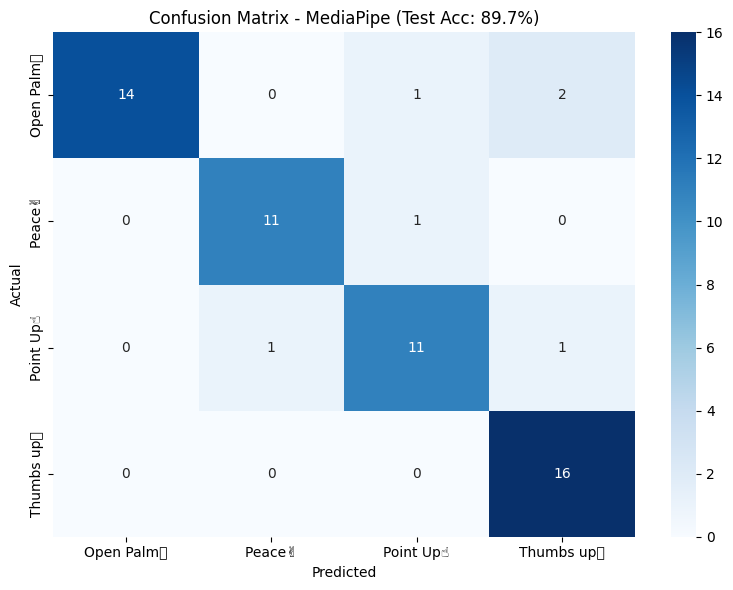

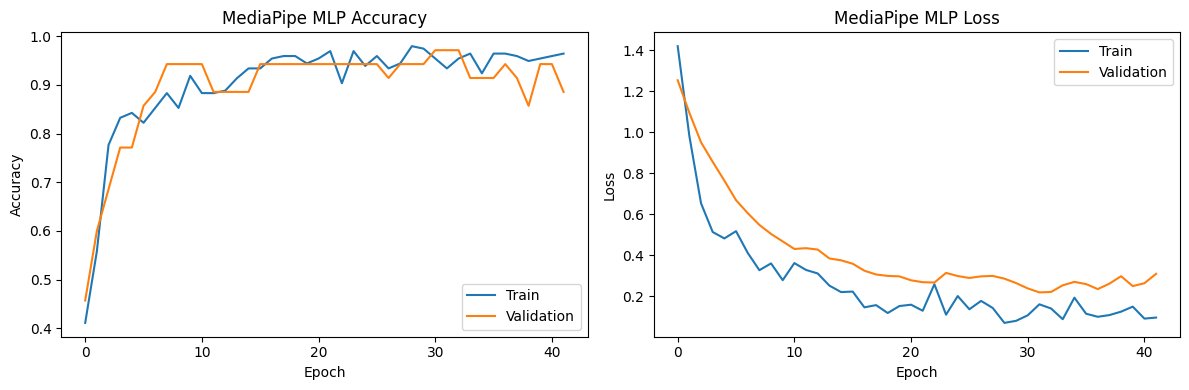

              precision    recall  f1-score   support

 Open Palm🖐️       1.00      0.82      0.90        17
     Peace✌️       0.92      0.92      0.92        12
  Point Up☝️       0.85      0.85      0.85        13
  Thumbs up👍       0.84      1.00      0.91        16

    accuracy                           0.90        58
   macro avg       0.90      0.90      0.90        58
weighted avg       0.90      0.90      0.90        58

 All saved!


In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Test accuracy
test_loss, test_acc = mlp.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n Test Accuracy: {test_acc*100:.2f}%")

# Confusion Matrix
y_pred = np.argmax(mlp.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title(f'Confusion Matrix - MediaPipe (Test Acc: {test_acc*100:.1f}%)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f"{save_dir}/mediapipe_confusion_matrix.png", dpi=150)
plt.show()

# Graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('MediaPipe MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('MediaPipe MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig(f"{save_dir}/mediapipe_graph.png", dpi=150)
plt.show()

report = classification_report(y_test, y_pred, target_names=class_names)
print(report)
print(" All saved!")

In [10]:
with open(f"{save_dir}/mediapipe_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(f"Test Accuracy: {test_acc*100:.2f}%\n\n")
    f.write(classification_report(y_test, y_pred, target_names=class_names))

np.save(f"{save_dir}/X_landmarks.npy", X)
np.save(f"{save_dir}/y_labels.npy", y)

print("All saved!")

All saved!


d:\gesture_project\mp_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2018 - loss: 3.2862
Epoch 1: val_loss improved from None to 2.72069, saving model to best_mlp_model.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.1980 - loss: 3.3110 - val_accuracy: 0.3429 - val_loss: 2.7207 - learning_rate: 7.0000e-04
Epoch 2/150
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.1875 - loss: 3.2678
Epoch 2: val_loss improved from 2.72069 to 2.66235, saving model to best_mlp_model.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1726 - loss: 3.4035 - val_accuracy: 0.3429 - val_loss: 2.6623 - learning_rate: 7.0000e-04
Epoch 3/150
 8/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3420 - loss: 3.1995  
Epoch 3: val_loss improved from 2.66235 to 2.62800, saving model to best_mlp_model.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2944 - loss: 3.1959 - val_accuracy: 0.4286 - val_loss: 2.6280 - learning_rate: 7.0000e-04
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2377 - loss: 3.1335 
Epoch 4: val_loss improved from 2.62800 to 2.60947, saving model to best_mlp_model.h5


...

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8376 - loss: 1.2030 - val_accuracy: 0.8857 - val_loss: 1.1391 - learning_rate: 2.8000e-04
Epoch 139/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8413 - loss: 1.2052 
Epoch 139: val_loss improved from 1.13912 to 1.13759, saving model to best_mlp_model.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8325 - loss: 1.2454 - val_accuracy: 0.8857 - val_loss: 1.1376 - learning_rate: 2.8000e-04
Epoch 140/150
10/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7643 - loss: 1.2903 
Epoch 140: val_loss improved from 1.13759 to 1.12892, saving model to best_mlp_model.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7665 - loss: 1.3389 - val_accuracy: 0.8857 - val_loss: 1.1289 - learning_rate: 2.8000e-04
Epoch 141/150
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7717 - loss: 1.3045 
Epoch 141: val_loss improved from 1.12892 to 1.12059, saving model to best_mlp_model.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7665 - loss: 1.3059 - val_accuracy: 0.8857 - val_loss: 1.1206 - learning_rate: 2.8000e-04
Epoch 142/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8019 - loss: 1.2843 
Epoch 142: val_loss did not improve from 1.12059
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7970 - loss: 1.2864 - val_accuracy: 0.8857 - val_loss: 1.1271 - learning_rate: 2.8000e-04
Epoch 143/150
 8/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8525 - loss: 1.1376 
Epoch 143: val_loss did not improve from 1.12059
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8071 - loss: 1.2556 - val_accuracy: 0.8857 - val_loss: 1.1293 - learning_rate: 2.8000e-04
Epoch 144/150
11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7845 - loss: 1.2806 
Epoch 144: val_loss did not improve from 1.12059

Epoch 144: ReduceLROnPlateau reducing learning rate to 0.00011199999134987594.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7716 - loss: 1.3402 - v

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step


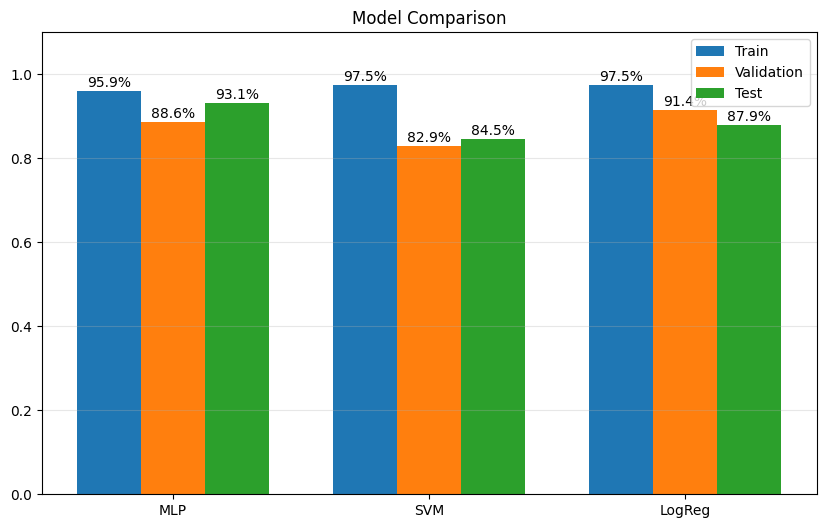

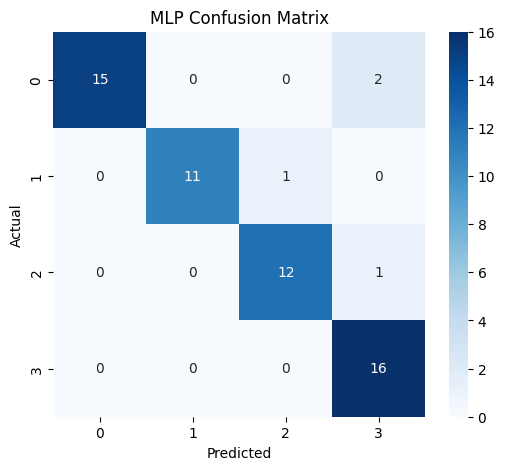


========== MLP CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

           0       1.00      0.88      0.94        17
           1       1.00      0.92      0.96        12
           2       0.92      0.92      0.92        13
           3       0.84      1.00      0.91        16

    accuracy                           0.93        58
   macro avg       0.94      0.93      0.93        58
weighted avg       0.94      0.93      0.93        58



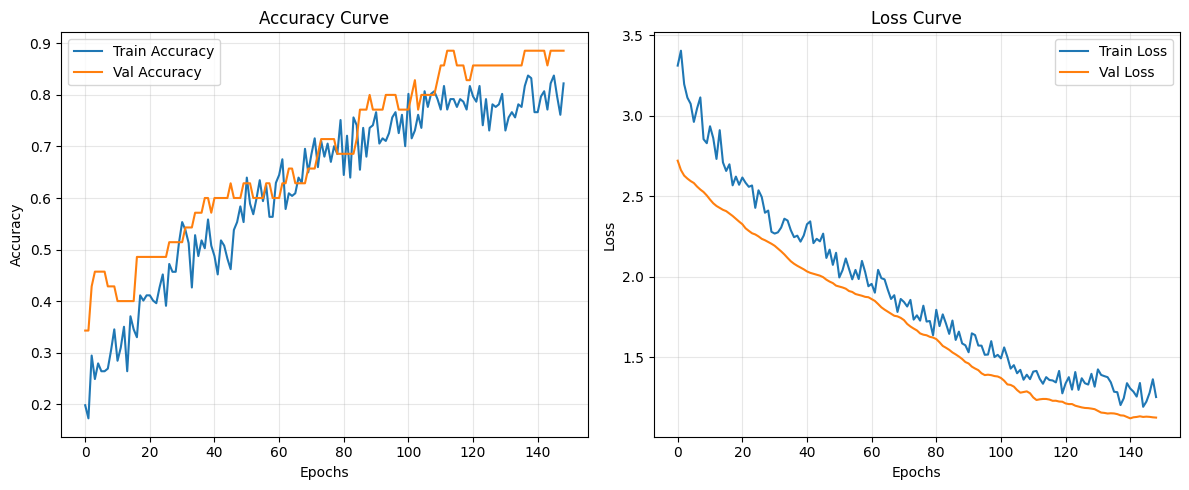


===== FINAL ACCURACY =====
MLP Test Accuracy:    93.10%
SVM Test Accuracy:    84.48%
LogReg Test Accuracy: 87.93%


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2


# =====================================================
# 1. SPLIT DATA
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)


# =====================================================
# 2. SCALING
# =====================================================
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")


# =====================================================
# 3. ONE HOT ENCODING
# =====================================================
num_classes = 4

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)


# =====================================================
# 4. STRONGER GENERALIZED MLP (FIXED OVERFITTING)
# =====================================================
mlp = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.01), input_shape=(63,)),
    BatchNormalization(),
    Dropout(0.6),

    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])


# =====================================================
# OPTIMIZER
# =====================================================
optimizer = Adam(learning_rate=0.0007)

mlp.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# =====================================================
# CALLBACKS (MORE STABLE GENERALIZATION)
# =====================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_mlp_model.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


# =====================================================
# 5. TRAIN MODEL
# =====================================================
history = mlp.fit(
    X_train_s, y_train_cat,
    validation_data=(X_val_s, y_val_cat),
    epochs=150,
    batch_size=16,
    callbacks=[early_stop, checkpoint, lr_scheduler],
    verbose=1
)


# =====================================================
# 6. LOAD BEST MODEL
# =====================================================
best_mlp = load_model("best_mlp_model.h5")


# =====================================================
# 7. PREDICTIONS
# =====================================================
y_pred_mlp = np.argmax(best_mlp.predict(X_test_s), axis=1)


# =====================================================
# 8. ACCURACY SCORES
# =====================================================
mlp_train = best_mlp.evaluate(X_train_s, y_train_cat, verbose=0)[1]
mlp_val   = best_mlp.evaluate(X_val_s, y_val_cat, verbose=0)[1]
mlp_test  = accuracy_score(y_test, y_pred_mlp)


# =====================================================
# 9. SVM
# =====================================================
svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train_s, y_train)

svm_train = accuracy_score(y_train, svm.predict(X_train_s))
svm_val   = accuracy_score(y_val, svm.predict(X_val_s))
svm_test  = accuracy_score(y_test, svm.predict(X_test_s))


# =====================================================
# 10. LOGISTIC REGRESSION
# =====================================================
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_s, y_train)

lr_train = accuracy_score(y_train, lr.predict(X_train_s))
lr_val   = accuracy_score(y_val, lr.predict(X_val_s))
lr_test  = accuracy_score(y_test, lr.predict(X_test_s))


# =====================================================
# 11. MODEL COMPARISON PLOT
# =====================================================
models = ['MLP', 'SVM', 'LogReg']

train_acc = [mlp_train, svm_train, lr_train]
val_acc   = [mlp_val, svm_val, lr_val]
test_acc  = [mlp_test, svm_test, lr_test]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

b1 = plt.bar(x - width, train_acc, width, label='Train')
b2 = plt.bar(x, val_acc, width, label='Validation')
b3 = plt.bar(x + width, test_acc, width, label='Test')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h+0.01,
                 f"{h*100:.1f}%", ha='center')

plt.xticks(x, models)
plt.ylim(0,1.1)
plt.title("Model Comparison")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


# =====================================================
# 12. CONFUSION MATRIX (MLP)
# =====================================================
cm = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =====================================================
# 13. CLASSIFICATION REPORT
# =====================================================
print("\n========== MLP CLASSIFICATION REPORT ==========\n")
print(classification_report(y_test, y_pred_mlp))


# =====================================================
# 14. TRAINING CURVES
# =====================================================
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# =====================================================
# 15. FINAL RESULTS
# =====================================================
print("\n===== FINAL ACCURACY =====")
print(f"MLP Test Accuracy:    {mlp_test*100:.2f}%")
print(f"SVM Test Accuracy:    {svm_test*100:.2f}%")
print(f"LogReg Test Accuracy: {lr_test*100:.2f}%")

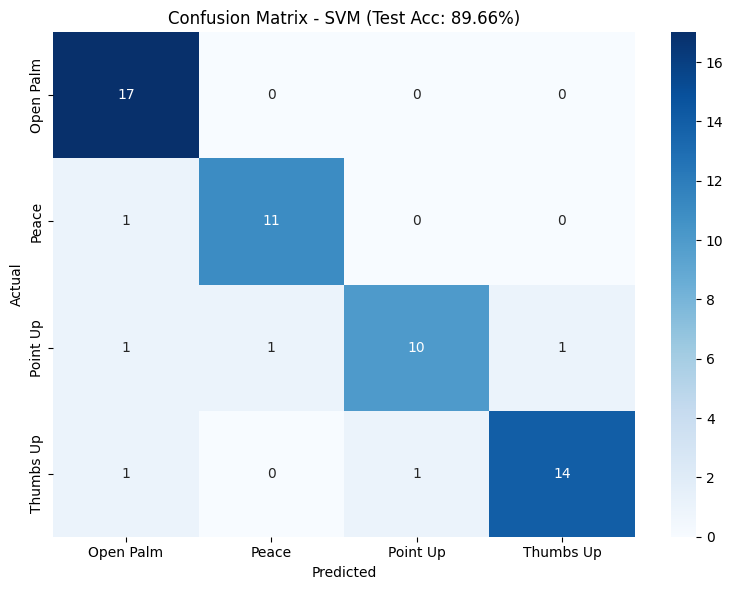

              precision    recall  f1-score   support

   Open Palm       0.85      1.00      0.92        17
       Peace       0.92      0.92      0.92        12
    Point Up       0.91      0.77      0.83        13
   Thumbs Up       0.93      0.88      0.90        16

    accuracy                           0.90        58
   macro avg       0.90      0.89      0.89        58
weighted avg       0.90      0.90      0.89        58



In [3]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

svm_model = models["SVM"]
y_pred = svm_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix - SVM (Test Acc: 89.66%)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(r"D:\gesture_project\results\svm_confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))

In [16]:
import numpy as np
import pickle
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report

# Load
model = load_model(r"D:\gesture_project\results\mediapipe_model.h5")
with open(r"D:\gesture_project\results\scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

X = np.load(r"D:\gesture_project\results\X_landmarks.npy")
y = np.load(r"D:\gesture_project\results\y_labels.npy")

class_names = ["Open Palm", "Peace", "Point Up", "Thumbs Up"]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

X_scaled = scaler.transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Predict
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
test_acc = np.mean(y_pred == y_test) * 100

print(f"Test Accuracy : {test_acc:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=class_names))

Test Accuracy : 91.38%

              precision    recall  f1-score   support

   Open Palm       1.00      0.88      0.94        17
       Peace       0.92      0.92      0.92        12
    Point Up       0.85      0.85      0.85        13
   Thumbs Up       0.89      1.00      0.94        16

    accuracy                           0.91        58
   macro avg       0.91      0.91      0.91        58
weighted avg       0.92      0.91      0.91        58



In [1]:
import mediapipe as mp
print(mp.__version__)

0.10.9


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import pickle
from tensorflow.keras.models import load_model

# =========================
# LOAD MODEL + SCALER
# =========================
model = load_model(r"D:\gesture_project\results\mediapipe_model.h5")

with open(r"D:\gesture_project\results\scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

class_names = ["Open Palm", "Peace", "Point Up", "Thumbs Up"]

# =========================
# MEDIAPIPE SETUP
# =========================
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.5
)
mp_draw = mp.solutions.drawing_utils

# =========================
# CAMERA
# =========================
cap = cv2.VideoCapture(0)

cv2.namedWindow("Gesture", cv2.WINDOW_NORMAL)

fullscreen = False

print("Press Q to quit | Press F for fullscreen")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = hands.process(rgb)

    label = "No hand detected"
    confidence = 0

    if result.multi_hand_landmarks:
        hand = result.multi_hand_landmarks[0]
        mp_draw.draw_landmarks(frame, hand, mp_hands.HAND_CONNECTIONS)

        coords = []
        for lm in hand.landmark:
            coords.extend([lm.x, lm.y, lm.z])

        coords = np.array(coords).reshape(1, -1)
        coords = scaler.transform(coords)

        pred = model.predict(coords, verbose=0)
        idx = np.argmax(pred)

        label = class_names[idx]
        confidence = pred[0][idx] * 100

    # =========================
    # UI TEXT
    # =========================
    color = (0, 255, 0) if confidence > 70 else (0, 165, 255)

    cv2.rectangle(frame, (0, 0), (450, 80), (0, 0, 0), -1)
    cv2.putText(frame, f"{label}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
    cv2.putText(frame, f"{confidence:.1f}%", (10, 65),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    cv2.imshow("Gesture", frame)

    key = cv2.waitKey(1) & 0xFF

    # quit
    if key == ord('q'):
        break

    # fullscreen toggle
    if key == ord('f'):
        fullscreen = not fullscreen
        if fullscreen:
            cv2.setWindowProperty("Gesture", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
        else:
            cv2.setWindowProperty("Gesture", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_NORMAL)

cap.release()
cv2.destroyAllWindows()

Press Q to quit | Press F for fullscreen


import mediapipe as mp
print(mp.__version__)

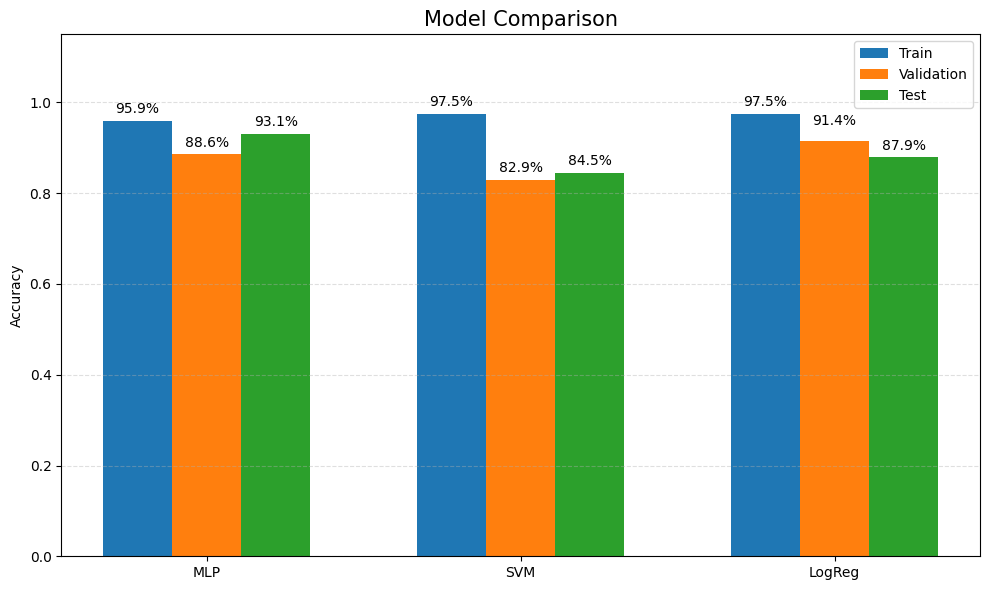

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = ['MLP', 'SVM', 'LogReg']

# Accuracy values
train_acc = [95.9, 97.5, 97.5]
val_acc   = [88.6, 82.9, 91.4]
test_acc  = [93.1, 84.5, 87.9]

# Convert to decimal
train = np.array(train_acc) / 100
val   = np.array(val_acc) / 100
test  = np.array(test_acc) / 100

# X positions
x = np.arange(len(models))
width = 0.22

# Figure
plt.figure(figsize=(10,6))

# Bars
bars1 = plt.bar(x - width, train, width, label='Train', color='#1f77b4')
bars2 = plt.bar(x,         val,   width, label='Validation', color='#ff7f0e')
bars3 = plt.bar(x + width, test,  width, label='Test', color='#2ca02c')

# Add labels with custom offsets
def add_labels(bars, values, offsets):
    for bar, value, offset in zip(bars, values, offsets):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset,
            f'{value:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10
        )

# Different offsets to avoid overlap
add_labels(bars1, train_acc, [0.01, 0.01, 0.01])
add_labels(bars2, val_acc,   [0.01, 0.01, 0.03])  # top-right fixed
add_labels(bars3, test_acc,  [0.01, 0.01, 0.01])

# Styling
plt.title('Model Comparison', fontsize=15)
plt.ylabel('Accuracy')
plt.xticks(x, models)

# Extra headroom
plt.ylim(0, 1.15)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Legend
plt.legend()

# Layout
plt.tight_layout()

# Show
plt.show()